# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Remove the directory if it already exists to ensure a fresh clone
if os.path.exists("scratchpad"):
    !rm -rf scratchpad

!git clone "https://github.com/asomers205/scratchpad.git"

### 1

print("------------------Q1------------------")

# Get airbnb data
file_path = "data/airbnb_NYC.csv"
if os.path.exists(file_path):
    airbnb = pd.read_csv(file_path, encoding='latin-1')
    print("File loaded successfully.")
else:
    print(f"Error: {file_path} not found.")

# Clean the Price variable
# I'm removing "$" and "," because it acts as a thousands separator ('1,112'), which stops Python from reading the string as a valid number.
# Using errors='coerce' ensures that any malformed strings are safely turned into NaNs.

airbnb['Price_Clean'] = (airbnb['Price']
                         .astype(str)
                         .str.replace('$', '', regex=False)
                         .str.replace(',', '', regex=False))

airbnb['Price_Clean'] = pd.to_numeric(airbnb['Price_Clean'], errors='coerce')

missing_count = airbnb['Price_Clean'].isnull().sum()
print(f"Number of missing values in cleaned Price: {missing_count}")

display(airbnb[['Price', 'Price_Clean']].head())


### 2

print("------------------Q2------------------")

# Load the mn_police data
mn_police_path = "data/mn_police_use_of_force.csv"
if os.path.exists(mn_police_path):
    mn_police = pd.read_csv(mn_police_path, encoding='latin-1')
    print("\nMinnesota police data loaded successfully.")
else:
    print(f"Error: {mn_police_path} not found.")

# Calculate proportion of missing subject_injury
prop_missing = mn_police['subject_injury'].isnull().mean()
print(f"Proportion of missing 'subject_injury' values: {prop_missing:.2%}")

# Cross-tabulate with force_type (using fillna for the table to see the 'Missing' category)
# This allows us to see if missingness is concentrated in specific force categories like 'Threat of Force'
injury_crosstab = pd.crosstab(mn_police['force_type'], mn_police['subject_injury'].fillna('Missing'), dropna=False)
print("\nCross-tabulation of force_type and subject_injury:")
display(injury_crosstab)

# Replace remaining missing values with 'Missing'
mn_police['subject_injury'] = mn_police['subject_injury'].fillna('Missing')
print(f"\nUnique values in cleaned 'subject_injury': {mn_police['subject_injury'].unique()}")


### 3

print("------------------Q3------------------")

# Load metabric data
metabric_path = "data/metabric.csv"
if os.path.exists(metabric_path):
    metabric = pd.read_csv(metabric_path, encoding='latin-1')
    print("\nMetabric data loaded successfully.")
else:
    print(f"Error: {metabric_path} not found.")

# Convert 'Overall Survival Status' to dummy
# 0 if deceased, 1 if living
metabric['Survival_Dummy'] = metabric['Overall Survival Status'].map({'1:DECEASED': 0, '0:LIVING': 1})

print("\nValue counts for Survival_Dummy:")
display(metabric['Survival_Dummy'].value_counts())
display(metabric[['Overall Survival Status', 'Survival_Dummy']].head())


### 4

print("------------------Q4------------------")

# Determine missing values for Review Scores Rating
missing_reviews = airbnb['Review Scores Rating'].isnull().sum()
print(f"\nNumber of missing values in 'Review Scores Rating': {missing_reviews}")

# Create a new variable, imputing the median score
median_rating = airbnb['Review Scores Rating'].median()
airbnb['Review_Scores_Imputed'] = airbnb['Review Scores Rating'].fillna(median_rating)

print(f"Median Review Score Rating: {median_rating}")
print(f"Missing values in 'Review_Scores_Imputed': {airbnb['Review_Scores_Imputed'].isnull().sum()}")

# Discussion of Bias:
# Imputing the median can bias results by artificially reducing the variance of the data.
# If the scores are not 'Missing Completely at Random' (ex properties with poor service
# are less likely to have reviews), then assuming they are average (median) will overstate
# the quality of those listings and potentially mask significant trends in the data.

Cloning into 'scratchpad'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 24 (delta 4), reused 4 (delta 4), pack-reused 16 (from 1)
Receiving objects: 100% (24/24), 25.56 KiB | 12.78 MiB/s, done.
Resolving deltas: 100% (5/5), done.
------------------Q1------------------
File loaded successfully.
Number of missing values in cleaned Price: 0


,Price,Price_Clean
0,145,145
1,37,37
2,28,28
3,199,199
4,549,549


------------------Q2------------------

Minnesota police data loaded successfully.
Proportion of missing 'subject_injury' values: 76.19%

Cross-tabulation of force_type and subject_injury:


subject_injury,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0



Unique values in cleaned 'subject_injury': ['Missing' 'No' 'Yes']
------------------Q3------------------

Metabric data loaded successfully.

Value counts for Survival_Dummy:


,count
Survival_Dummy,
0,768
1,575


,Overall Survival Status,Survival_Dummy
0,0:LIVING,1
1,1:DECEASED,0
2,0:LIVING,1
3,1:DECEASED,0
4,1:DECEASED,0


------------------Q4------------------

Number of missing values in 'Review Scores Rating': 8323
Median Review Score Rating: 94.0
Missing values in 'Review_Scores_Imputed': 0


**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

------------------Q1------------------
Shark data loaded successfully using pd.read_excel.
Total rows loaded: 7074
------------------Q2------------------
Columns remaining: ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


------------------Q3------------------
------------------Q4------------------
Rows before year filtering: 7074
Rows after year filtering (since 1940): 5538


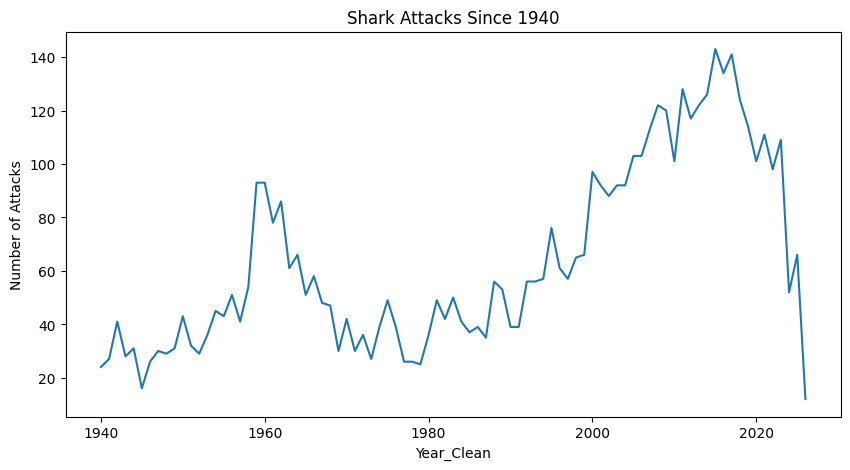

The range of years in the modern subset is: 1940.0 to 2026.0
Attacks appear to be increasing over time, though this may be due to better reporting.
------------------Q5------------------


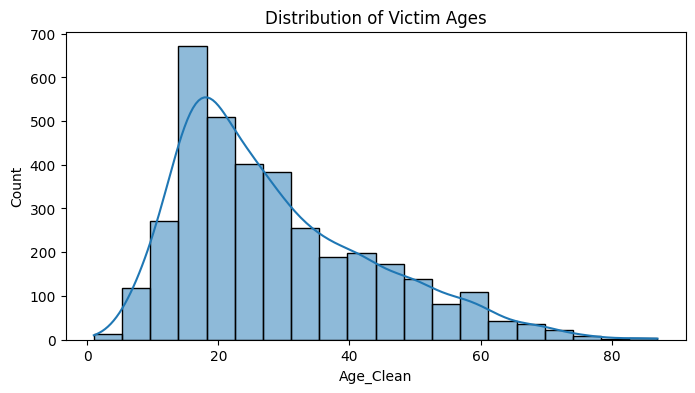

------------------Q6------------------
Proportion of unprovoked attacks: 74.50%
------------------Q7------------------
------------------Q8------------------
Fatality Rates by Attack Type:


Fatal_Clean,N,Unknown,Y
Type_Clean,,,
Provoked,0.957935,0.017208,0.024857
Unknown,0.411699,0.449944,0.138358
Unprovoked,0.818953,0.012845,0.168202


In [33]:
# Q2.1 Loading the shark attack data
# the pd.read_excel() function is the correct method to use.

print("------------------Q1------------------")


# Load the Excel file
sharks = pd.read_excel('GSAF5.xls')
print("Shark data loaded successfully using pd.read_excel.")
print(f"Total rows loaded: {len(sharks)}")

# Q2.2 Drop columns that do not contain data

print("------------------Q2------------------")


# We drop columns where all values are NaN
sharks = sharks.dropna(axis=1, how='all')

print(f"Columns remaining: {sharks.columns.tolist()}")
display(sharks.head())

# Q2.3 What is an observation?

print("------------------Q3------------------")


# An observation in this dataset represents a single reported shark attack incident.
# This affects cleaning because duplicate entries or rows with no incident data should be removed,
# and analysis must account for the fact that one incident might involve multiple victims (though usually it's 1:1).

# Q2.4 Clean the Year variable

print("------------------Q4------------------")


sharks['Year_Clean'] = pd.to_numeric(sharks['Year'], errors='coerce')

print(f"Rows before year filtering: {len(sharks)}")

# Filter for attacks since 1940
sharks_modern = sharks[sharks['Year_Clean'] >= 1940].copy()

print(f"Rows after year filtering (since 1940): {len(sharks_modern)}")

yearly_counts = sharks_modern.groupby('Year_Clean').size()
plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='line', title='Shark Attacks Since 1940')
plt.ylabel('Number of Attacks')
plt.show()

print("The range of years in the modern subset is:", sharks_modern['Year_Clean'].min(), "to", sharks_modern['Year_Clean'].max())
print("Attacks appear to be increasing over time, though this may be due to better reporting.")

# Q2.5 Clean Age variable and make a histogram

print("------------------Q5------------------")

sharks_modern['Age_Clean'] = pd.to_numeric(sharks_modern['Age'], errors='coerce')

plt.figure(figsize=(8, 4))
sns.histplot(sharks_modern['Age_Clean'].dropna(), bins=20, kde=True)
plt.title('Distribution of Victim Ages')
plt.show()

# Q2.6 Clean 'Type'

print("------------------Q6------------------")


def clean_type(val):
    val = str(val).strip().capitalize()
    if 'Provoked' in val and 'Un' not in val:
        return 'Provoked'
    elif 'Unprovoked' in val:
        return 'Unprovoked'
    else:
        return 'Unknown'

sharks_modern['Type_Clean'] = sharks_modern['Type'].apply(clean_type)
prop_unprovoked = (sharks_modern['Type_Clean'] == 'Unprovoked').mean()
print(f"Proportion of unprovoked attacks: {prop_unprovoked:.2%}")

# Q2.7 Clean 'Fatal Y/N'

print("------------------Q7------------------")


def clean_fatal(val):
    val = str(val).strip().upper()
    if val == 'Y': return 'Y'
    if val == 'N': return 'N'
    return 'Unknown'

# Correcting the column reference from 'Fatal (Y/N)' to 'Fatal Y/N'
sharks_modern['Fatal_Clean'] = sharks_modern['Fatal Y/N'].apply(clean_fatal)

# Q2.8 Likelihood of fatality by Type

print("------------------Q8------------------")

fatal_cross = pd.crosstab(sharks_modern['Type_Clean'], sharks_modern['Fatal_Clean'], normalize='index')
print("Fatality Rates by Attack Type:")
display(fatal_cross)

# Thoughts:
# Typically, unprovoked attacks might be more fatal if they involve larger sharks/predatory behavior,
# whereas provoked attacks often involve handling smaller sharks, leading to non-fatal bites."

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

Q3. Tidy Data Analysis

1. **Abstract:** The paper describes a standard way of organizing data values within a dataset called "tidy data." It focuses on the relationship between the structure of the data and its semantics (what the data actually represents).

2. **Introduction:** The tidy data standard is intended to facilitate data cleaning and analysis by providing a consistent structure. This allows tools to be built around a single, predictable format, reducing the time spent on reformatting data.

3. **Section 2 Intro:**
    * *"Like families..."*: This means that while all tidy datasets follow the same specific rules, there are infinite ways for data to be disorganized or "messy."
    * *"Difficulty defining variables/observations"*: While it's easy to see columns and rows in a specific table, creating a universal, formal definition that works for every possible dataset is complex because the same data can be structured in many ways.

4. **Section 2.2 Definitions:**
    * **Values:** Each number or string in the dataset.
    * **Variables:** Measures of an attribute (e.g., height, temperature, age).
    * **Observations:** All values measured on the same unit (e.g., a specific person or day).

5. **Section 2.3 Tidy Data:**
    1. Each variable forms a column.
    2. Each observation forms a row.
    3. Each type of observational unit forms a table.

6. **Section 3 common problems:**
    1. Column headers are values, not variable names.
    2. Multiple variables are stored in one column.
    3. Variables are stored in both rows and columns.
    4. Multiple types of observational units are stored in the same table.
    5. A single observational unit is stored in multiple tables.

    * **Table 4 is messy** because the column headers (religion, income brackets) are actually values of variables.
    * **Melting** is the process of transforming a dataset from a wide format to a long format, where column headers become values in a new column.

7. **Table 11 vs 12:** Table 11 is messy because it has variables (element: TMIN, TMAX) stored in rows rather than columns. Table 12 is tidy because it has been "molten" and reshaped so that each variable has its own column and each day/measurement is its own row.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

------------------Q1------------------
          ID    OPEID                     Institution Name          City  \
0          1   102000        Jacksonville State University  Jacksonville   
1          2   104700                      Troy University          Troy   
2          3   105100                University of Alabama    Tuscaloosa   
3          4   105100                University of Alabama    Tuscaloosa   
4          5   105100                University of Alabama    Tuscaloosa   
...      ...      ...                                  ...           ...   
28216  28217  4279700  Albert Einstein College of Medicine         Bronx   
28217  28218  4279700  Albert Einstein College of Medicine         Bronx   
28218  28219  4279700  Albert Einstein College of Medicine         Bronx   
28219  28220  4279700  Albert Einstein College of Medicine         Bronx   
28220  28221  4279700  Albert Einstein College of Medicine         Bronx   

      State  Foreign Gift Received Date  Foreign

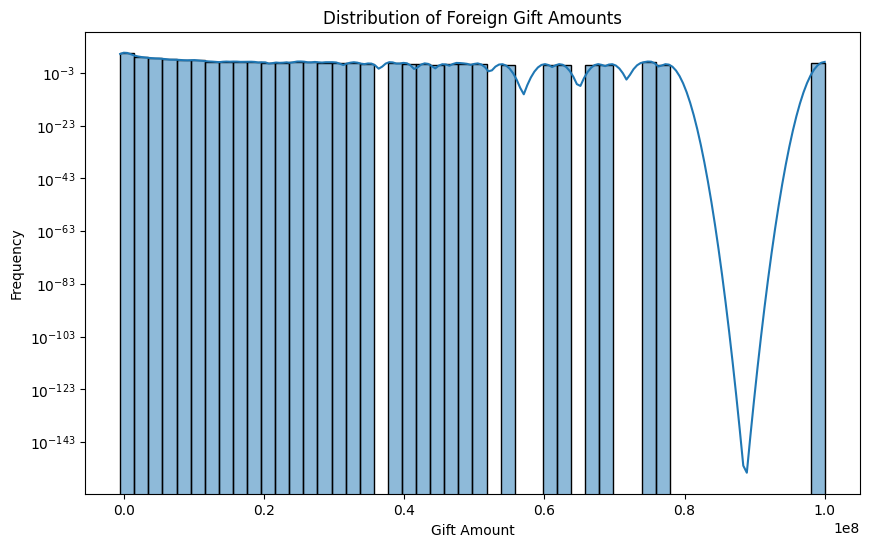

------------------Q3------------------


,Count,Proportion
Gift Type,,
Contract,17274,0.612097
Monetary Gift,10936,0.387513
Real Estate,11,0.000390


Proportion of Contract gifts: 61.21%
Proportion of Real Estate gifts: 0.04%
Proportion of Monetary gifts: 0.00%
--- Q4.4: Top 15 Countries ---

Top 15 Countries by Number of Gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

Top 15 Countries by Total Amount Given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    53

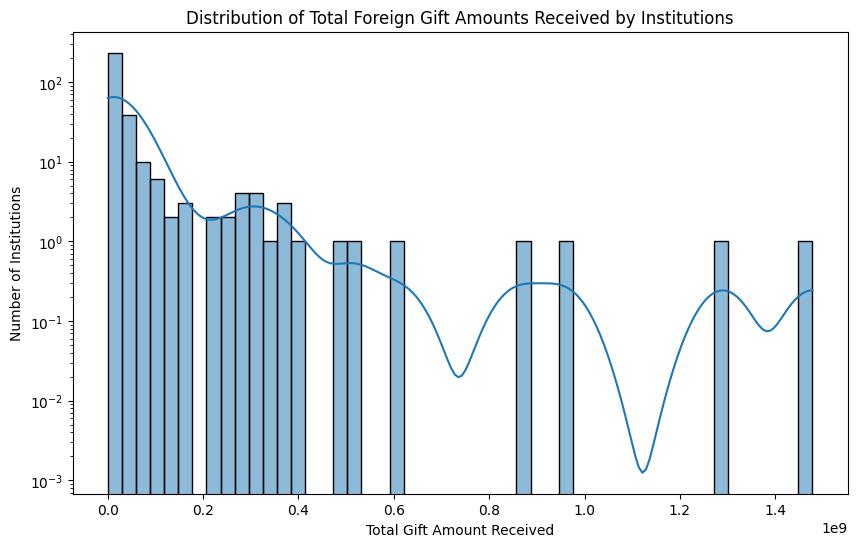


--- Q4.6: Top Giftors ---

Top 15 Giftors by Total Amount Provided:
State
MA    2493568427
NY    2085517871
PA    1968832896
CA    1837590509
TX    1135581916
IL    1022399605
CT     629687242
MD     582138946
DC     550530932
CO     436572703
NC     421626514
AZ     357499192
MI     354379746
UT     330061627
IN     283089863
Name: Foreign Gift Amount, dtype: int64


In [47]:
# Q4

print("------------------Q1------------------")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
gifts = pd.read_csv('data/ForeignGifts_edu.csv')
print(gifts)

print("------------------Q2------------------")
# 2. Descriptive statistics and histogram for 'Foreign Gift Amount'
print(gifts['Foreign Gift Amount'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(gifts['Foreign Gift Amount'], bins=50, kde=True)
plt.title('Distribution of Foreign Gift Amounts')
plt.xlabel('Gift Amount')
plt.ylabel('Frequency')
plt.yscale('log') # Using log scale because gift amounts often vary by orders of magnitude
plt.show()

print("------------------Q3------------------")
# 3. Value counts and proportions for Gift Type
gift_type_counts = gifts['Gift Type'].value_counts()
gift_type_props = gifts['Gift Type'].value_counts(normalize=True)

display(pd.DataFrame({'Count': gift_type_counts, 'Proportion': gift_type_props}))

# Specific proportions requested: 'Contract', 'Real Estate', and 'Monetary'
# Note: Column values might need stripping or checking exact names
specific_types = ['Contract', 'Real Estate', 'Monetary']
for gtype in specific_types:
    prop = gift_type_props.get(gtype, 0)
    print(f"Proportion of {gtype} gifts: {prop:.2%}")


print("--- Q4.4: Top 15 Countries ---")
# 4. Top 15 countries by number of gifts and total amount
top_countries_count = gifts.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)
top_countries_sum = gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

print("\nTop 15 Countries by Number of Gifts:")
print(top_countries_count)
print("\nTop 15 Countries by Total Amount Given:")
print(top_countries_sum)

print("\n--- Q4.5: Top 15 Institutions and Distribution ---")
# 5. Top 15 institutions by total amount received
institution_totals = gifts.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
top_institutions = institution_totals.head(15)

print("\nTop 15 Institutions by Total Amount Received:")
print(top_institutions)

# Histogram of total amount received by all institutions
plt.figure(figsize=(10, 6))
sns.histplot(institution_totals, bins=50, kde=True)
plt.title('Distribution of Total Foreign Gift Amounts Received by Institutions')
plt.xlabel('Total Gift Amount Received')
plt.ylabel('Number of Institutions')
plt.yscale('log')
plt.show()

print("\n--- Q4.6: Top Giftors ---")
# 6. Top giftors by total amount provided
# Checking for 'Foreign Giftor Name' or similar column. Assuming 'Foreign Giftor Name'
top_giftors = gifts.groupby('State')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\nTop 15 Giftors by Total Amount Provided:")
print(top_giftors)

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

------------------Q5.1------------------
File loaded successfully.
Loaded: data/college_completion.csv
Loaded: data/college_completion.csv

------------------Q5.2------------------
Shape (rows, columns): (3798, 4)

First 5 rows:


,level,aid_value,control,grad_100_value
0,4-year,7142.0,Public,10.0
1,4-year,6088.0,Public,29.4
2,4-year,2540.0,Private not-for-profit,0.0
3,4-year,6647.0,Public,16.5
4,4-year,7256.0,Public,8.8


------------------Q5.3------------------
Crosstab: control x level


level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


Row % (within control):


level,2-year,4-year
control,,
Private for-profit,46.9,53.1
Private not-for-profit,5.4,94.6
Public,59.4,40.6


------------------Q5.4------------------
Overall grad_100_value describe:


,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


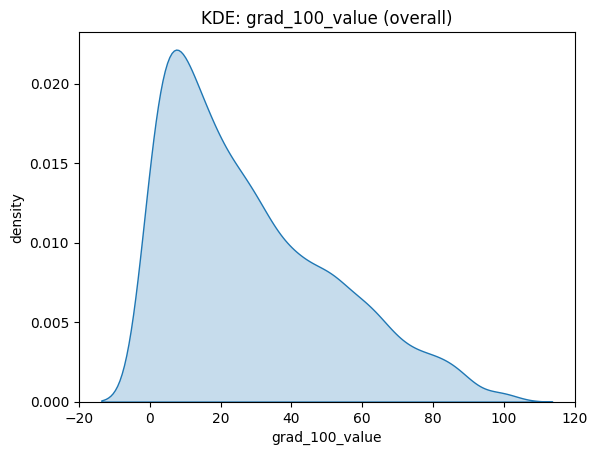

grad_100_value describe by control:


,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


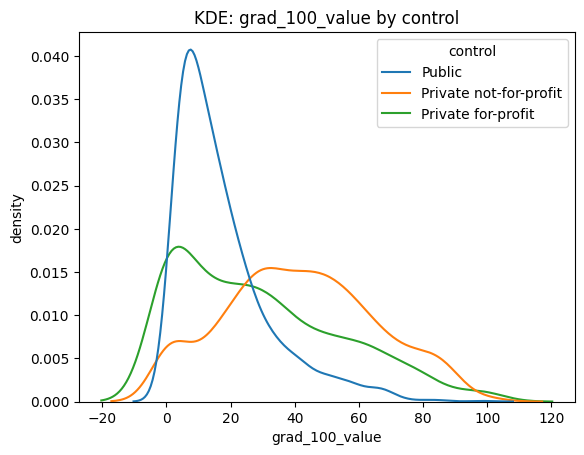

------------------Q5.5------------------


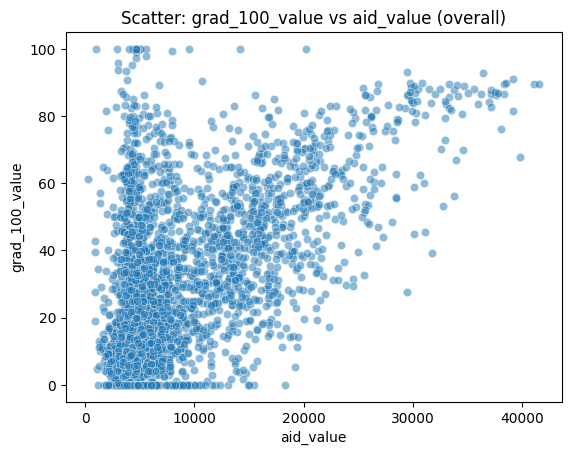

Overall covariance(aid_value, grad_100_value): 88,610.4832
Overall correlation(aid_value, grad_100_value): 0.5759



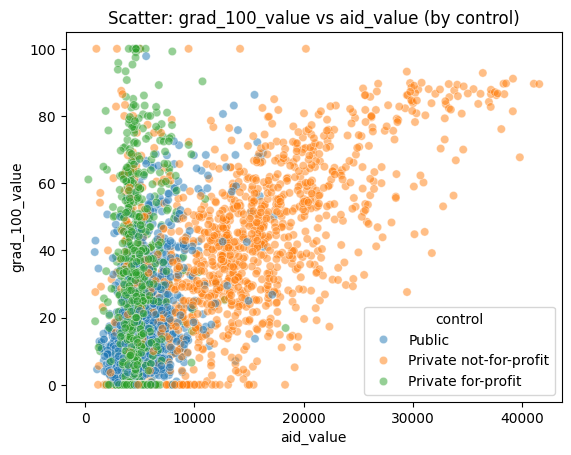

Covariance/Correlation by control:


,control,n,covariance,correlation
0,Private for-profit,778,6897.524957,0.188363
1,Private not-for-profit,1189,109274.123337,0.601591
2,Public,1499,15355.146212,0.482481


In [43]:
# Q5
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("------------------Q5.1------------------")

file_path = "data/college_completion.csv"
if os.path.exists(file_path):
    college = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
    print("File loaded successfully.")
    print(f"Loaded: {file_path}")
else:
    print(f"Error: {file_path} not found.")

college = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
print(f"Loaded: {file_path}")
print()

# Keep only relevant columns (as requested)
cols = ["level", "aid_value", "control", "grad_100_value"]
missing = [c for c in cols if c not in college.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

df = college[cols].copy()

# Make sure numeric columns are numeric
for c in ["aid_value", "grad_100_value"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# 2) Observations/variables + .head()
# ----------------------------
print("------------------Q5.2------------------")
print("Shape (rows, columns):", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# ----------------------------
# 3) Crosstab control x level + describe patterns
# ----------------------------
print("------------------Q5.3------------------")
ct = pd.crosstab(df["control"], df["level"], dropna=False)
print("Crosstab: control x level")
display(ct)

# Optional: row % to help you describe patterns
ct_rowpct = ct.div(ct.sum(axis=1), axis=0) * 100
print("Row % (within control):")
display(ct_rowpct.round(1))

# ----------------------------
# 4) KDE of grad_100_value + describe tables (overall and by control)
# ----------------------------
print("------------------Q5.4------------------")

# Overall describe table
overall = df["grad_100_value"].dropna()
print("Overall grad_100_value describe:")
display(overall.describe())

# Overall KDE
plt.figure()
sns.kdeplot(data=df, x="grad_100_value", fill=True)
plt.title("KDE: grad_100_value (overall)")
plt.xlabel("grad_100_value")
plt.ylabel("density")
plt.show()

# By control: describe tables
by_control_desc = df.groupby("control")["grad_100_value"].describe()
print("grad_100_value describe by control:")
display(by_control_desc)

# By control KDE (all on one plot for comparison)
plt.figure()
sns.kdeplot(data=df, x="grad_100_value", hue="control", fill=False, common_norm=False)
plt.title("KDE: grad_100_value by control")
plt.xlabel("grad_100_value")
plt.ylabel("density")
plt.show()


print("------------------Q5.5------------------")

# Drop missing for pairwise computations
pair = df[["aid_value", "grad_100_value"]].dropna()

# Scatter (overall)
plt.figure()
sns.scatterplot(data=pair, x="aid_value", y="grad_100_value", alpha=0.5)
plt.title("Scatter: grad_100_value vs aid_value (overall)")
plt.xlabel("aid_value")
plt.ylabel("grad_100_value")
plt.show()

# Covariance + correlation (overall)
cov_overall = pair["aid_value"].cov(pair["grad_100_value"])
corr_overall = pair["aid_value"].corr(pair["grad_100_value"])
print(f"Overall covariance(aid_value, grad_100_value): {cov_overall:,.4f}")
print(f"Overall correlation(aid_value, grad_100_value): {corr_overall:,.4f}")
print()

# Conditioning on control: scatter with hue + group stats
pair2 = df[["aid_value", "grad_100_value", "control"]].dropna()

plt.figure()
sns.scatterplot(data=pair2, x="aid_value", y="grad_100_value", hue="control", alpha=0.5)
plt.title("Scatter: grad_100_value vs aid_value (by control)")
plt.xlabel("aid_value")
plt.ylabel("grad_100_value")
plt.legend(title="control")
plt.show()

# Cov/corr by control
stats = []
for ctrl, sub in pair2.groupby("control"):
    cov = sub["aid_value"].cov(sub["grad_100_value"])
    corr = sub["aid_value"].corr(sub["grad_100_value"])
    n = len(sub)
    stats.append({"control": ctrl, "n": n, "covariance": cov, "correlation": corr})

stats_df = pd.DataFrame(stats).sort_values("control")
print("Covariance/Correlation by control:")
display(stats_df)

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

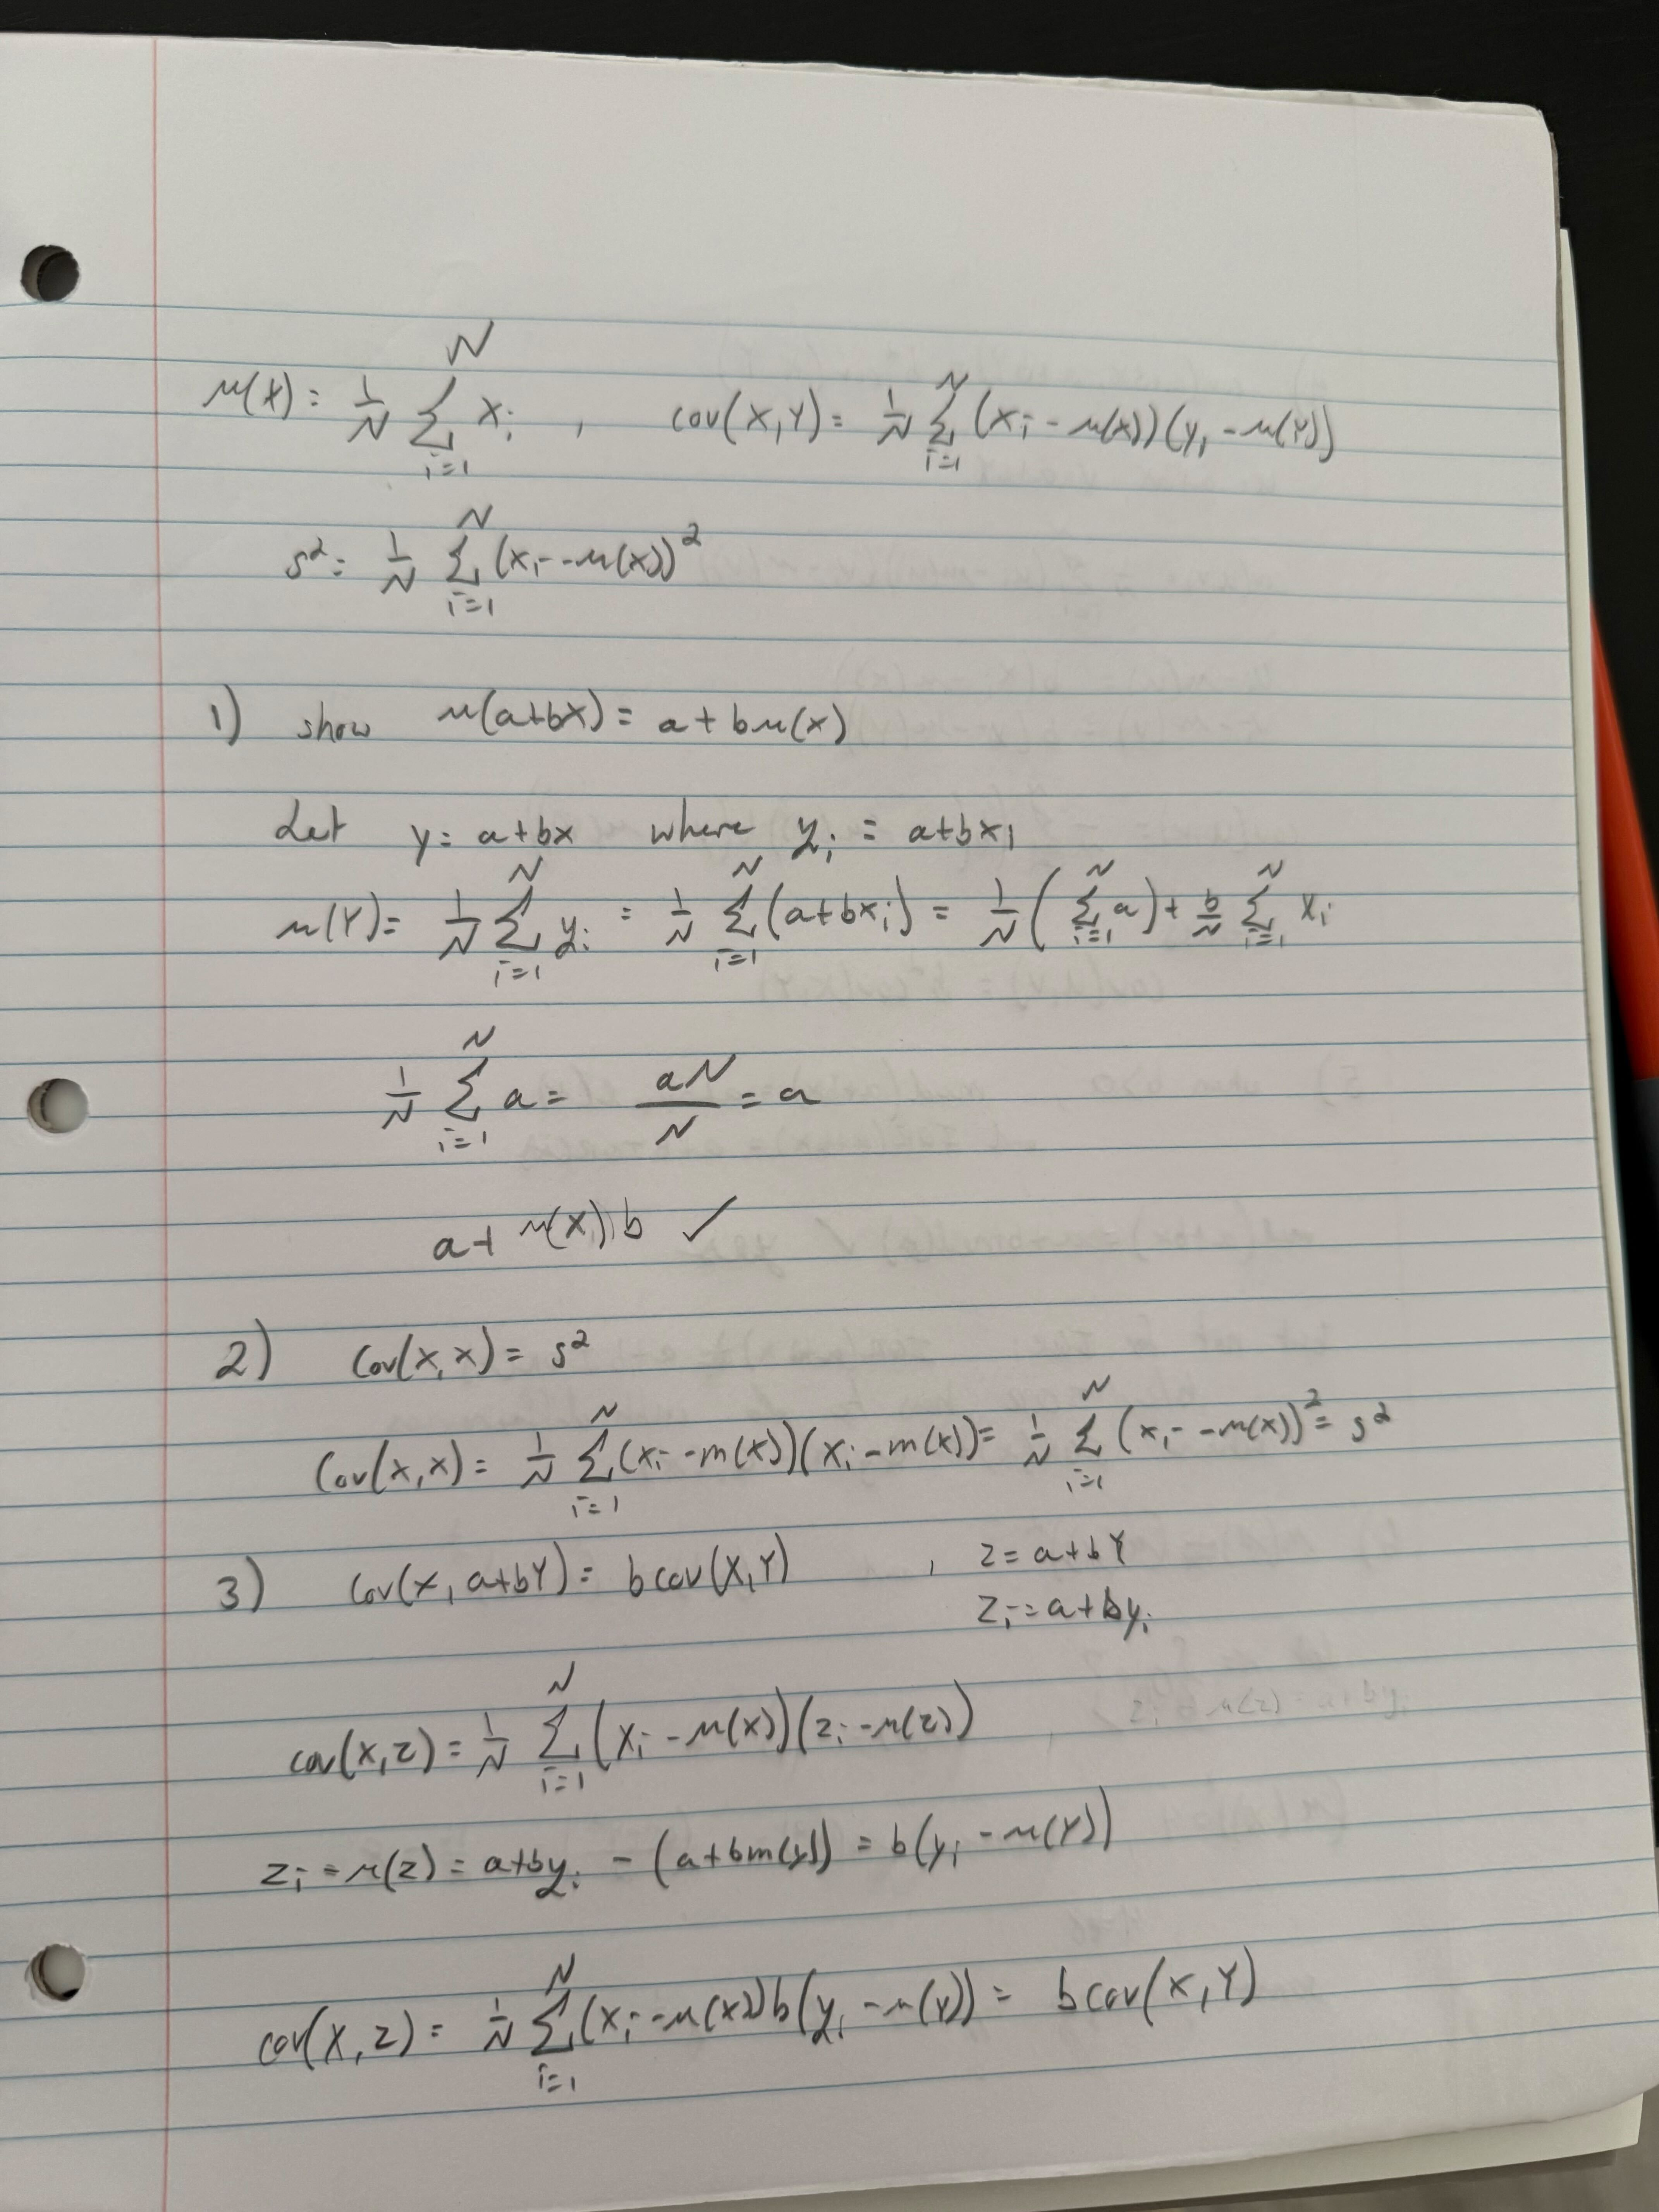

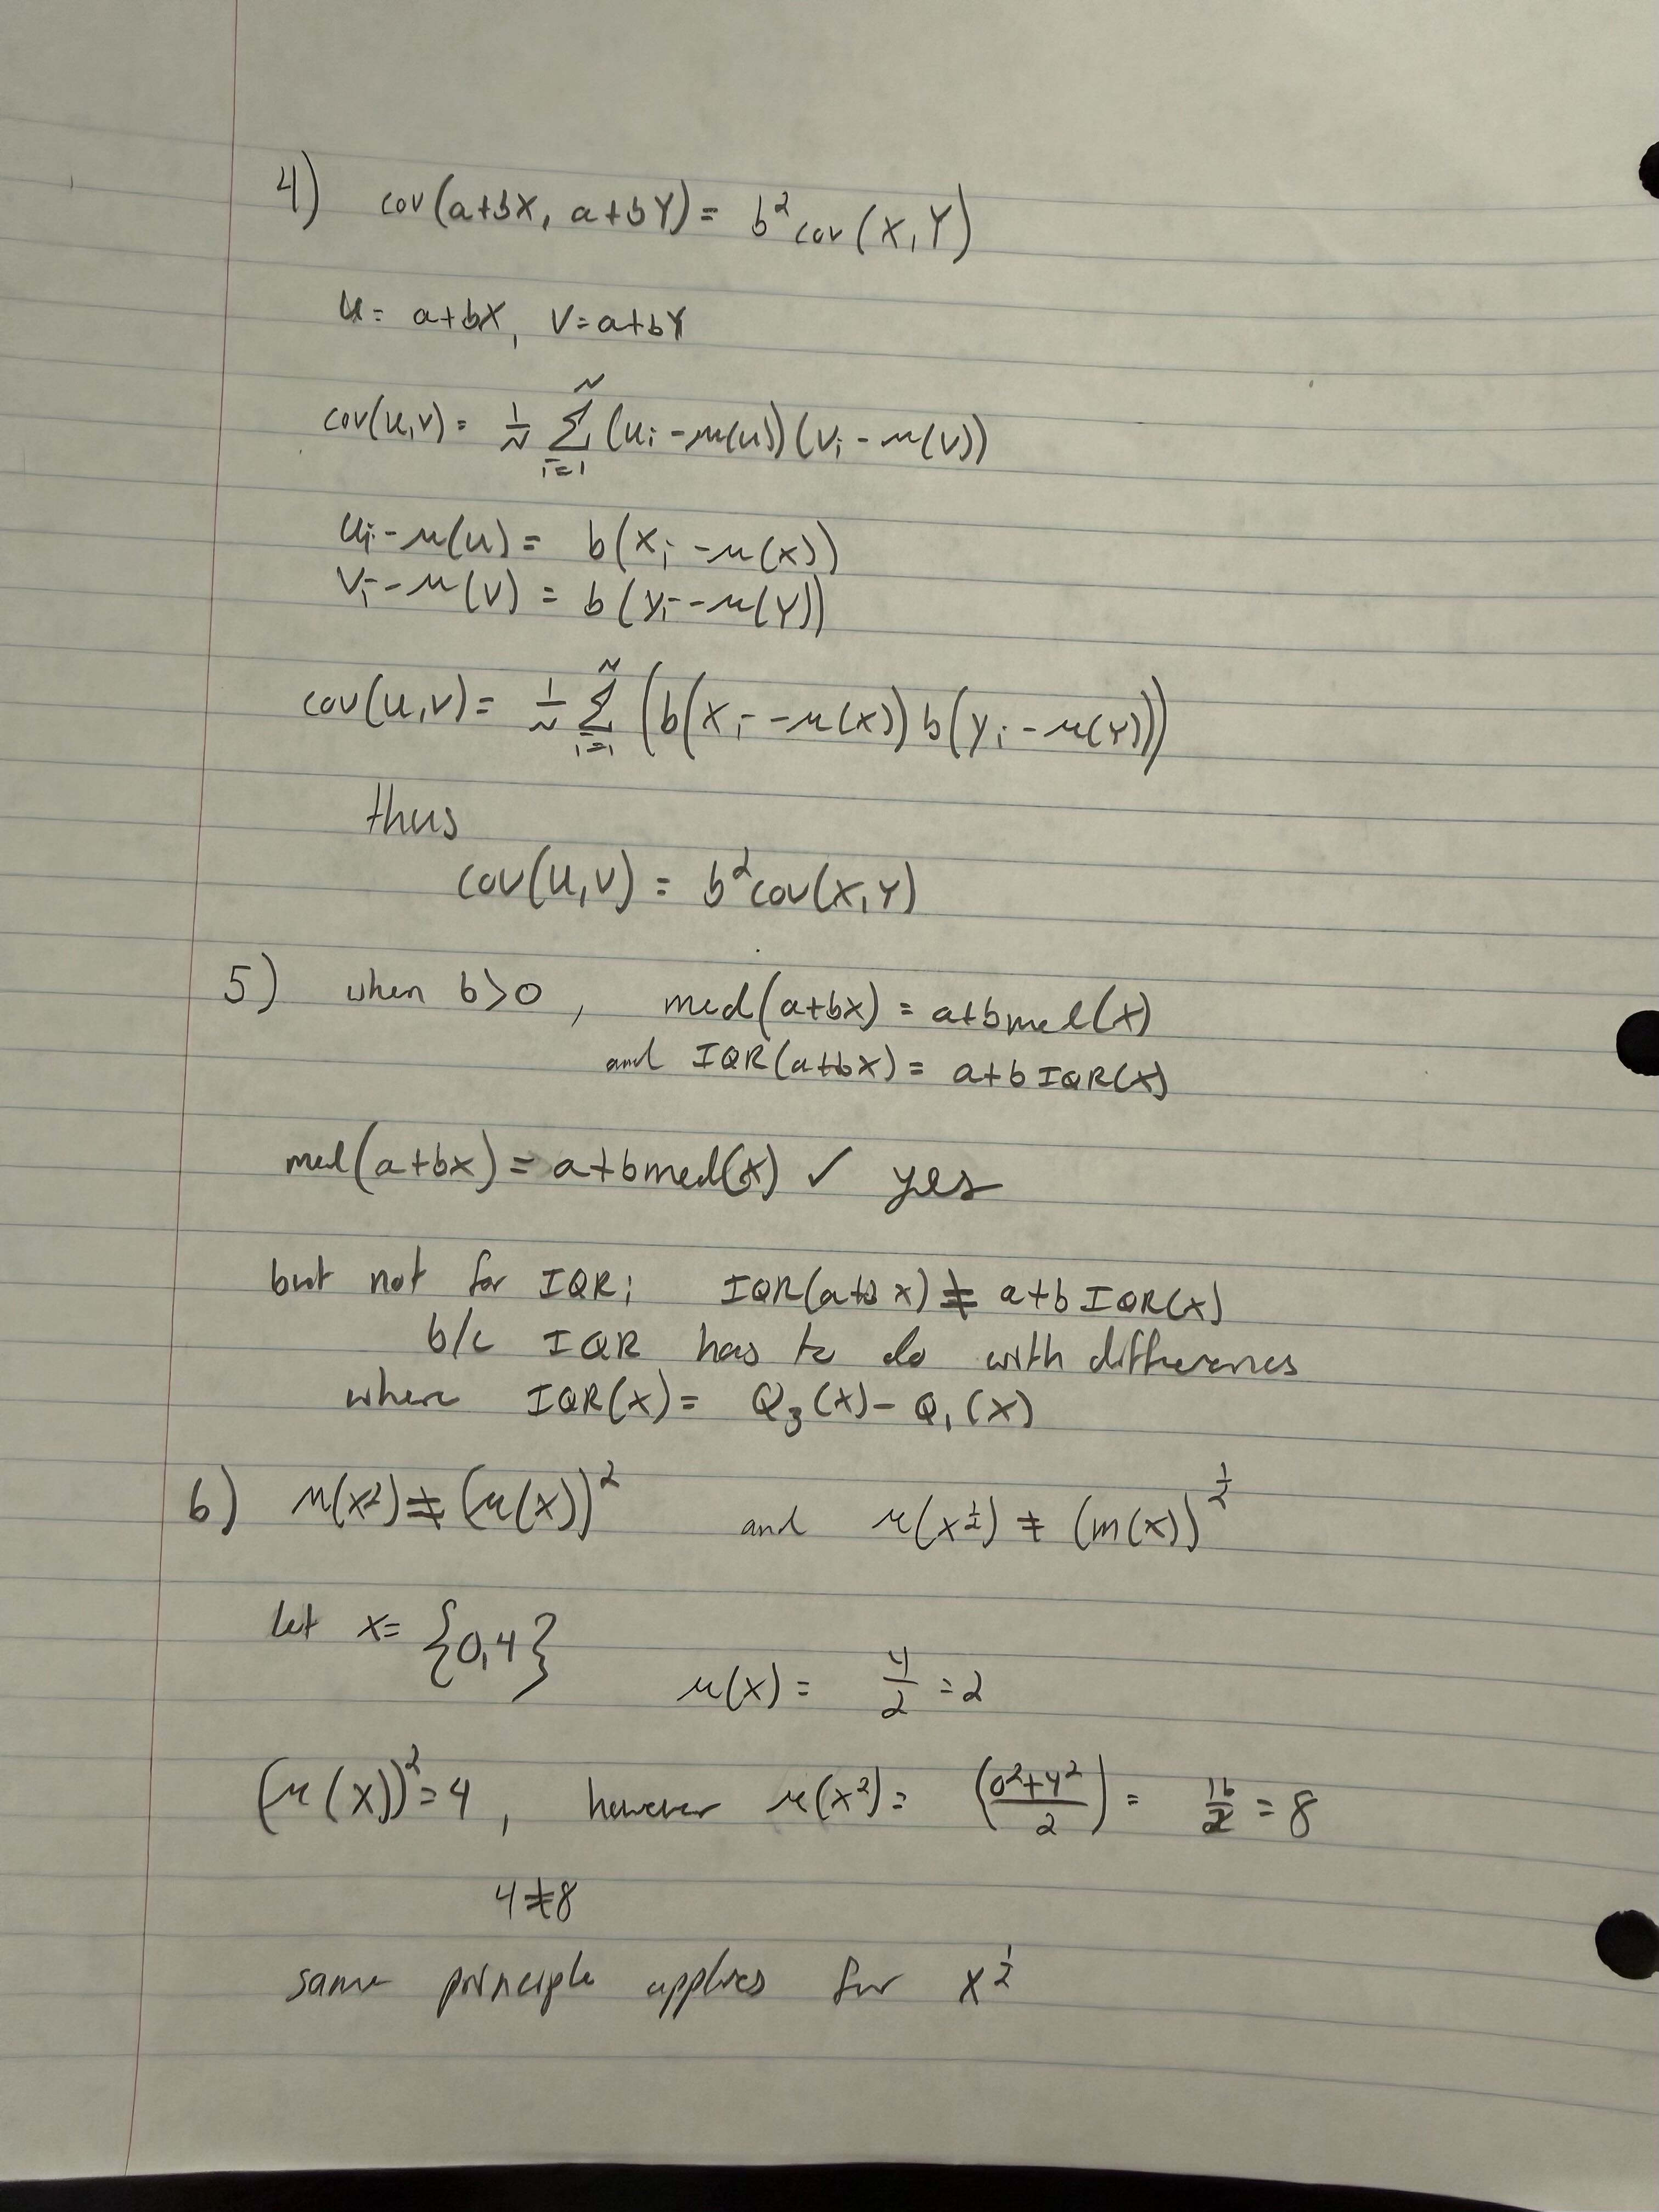

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

------------------Q7------------------
File loaded successfully.
Loaded: data/ames_prices.csv
------------------Q7.2------------------
Overall price describe:


,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


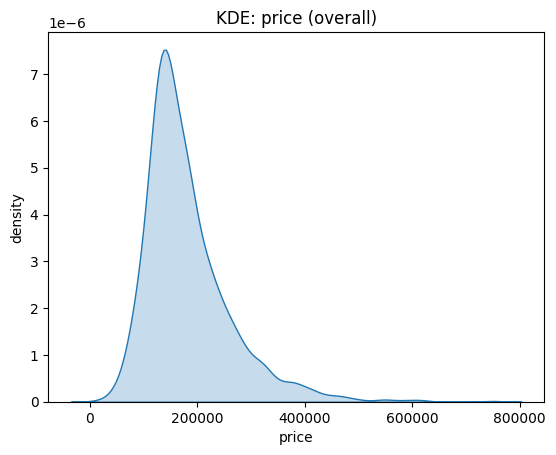

/tmp/ipython-input-1400555555.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Bldg.Type")


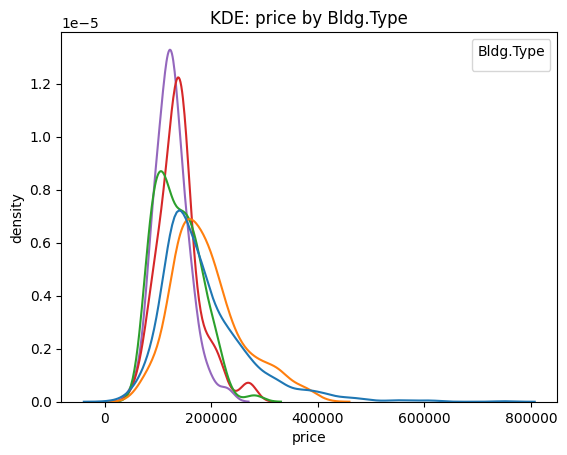

Price describe by Bldg.Type:


,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


Mean price by Bldg.Type (descending):


,price
Bldg.Type,
TwnhsE,192311.914163
1Fam,184812.041237
Duplex,139808.935780
Twnhs,135934.059406
2fmCon,125581.709677


Variance of price by Bldg.Type (ddof=0, descending):


,price
Bldg.Type,
1Fam,6.856622e+09
TwnhsE,4.362542e+09
Twnhs,1.741459e+09
Duplex,1.545855e+09
2fmCon,9.509515e+08


------------------Q7.3------------------


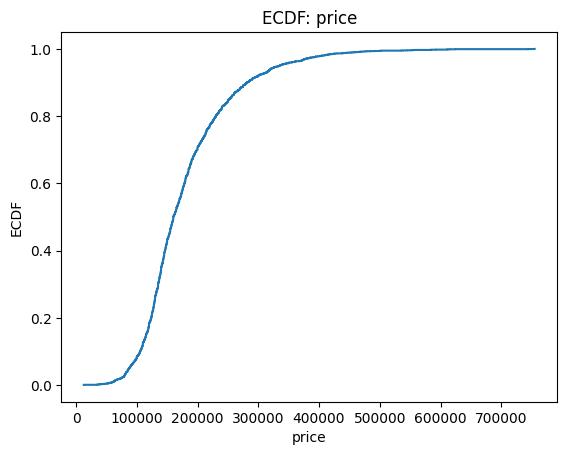

5-number summary for price:


,0
min,12789.0
q25,129500.0
median,160000.0
q75,213500.0
max,755000.0


------------------Q7.4------------------


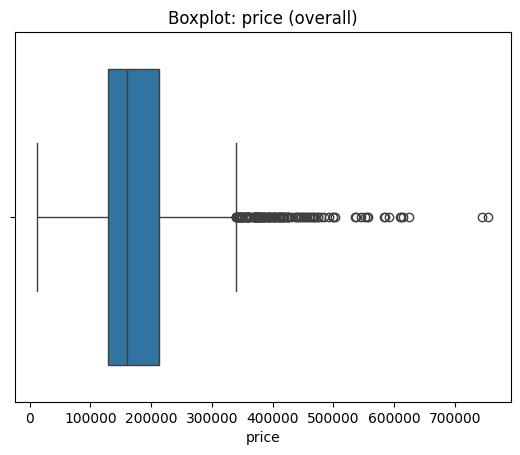

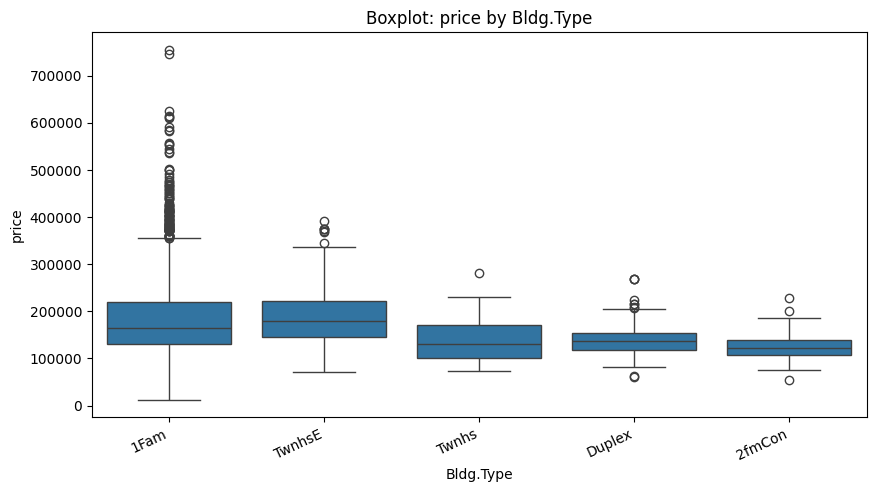

------------------Q7.5------------------
Outlier rule (IQR):
  Q1   = 129500.0
  Q3   = 213500.0
  IQR  = 84000.0
  Lower bound = 3500.0
  Upper bound = 339500.0

Outlier counts (0=not outlier, 1=outlier):


,count
is_outlier,
0,2793
1,137


------------------Q7.6------------------
Winsorized price describe:


,price_winsor
count,2930.000000
mean,177082.283959
std,67906.837135
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,339500.000000


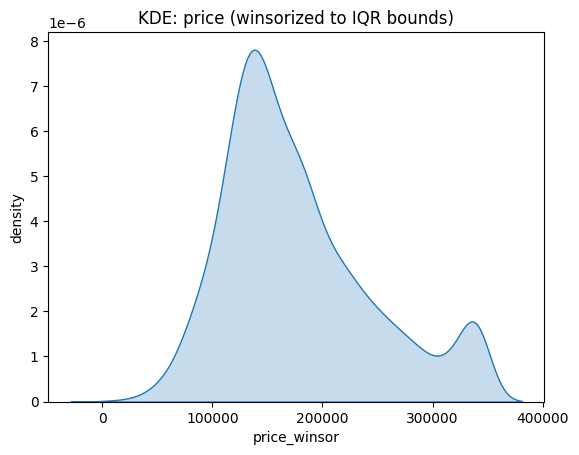

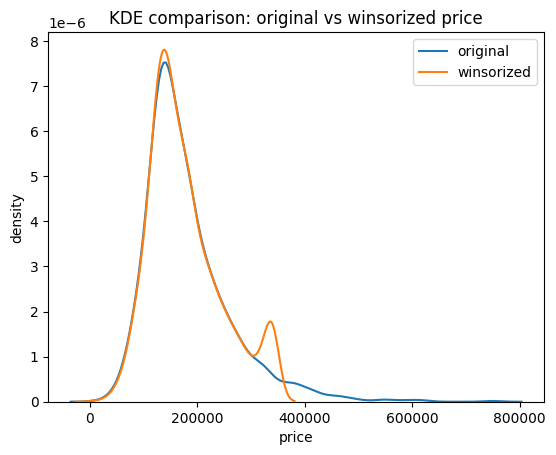

In [50]:
# Q7 — Exploratory Data Analysis & Visualization (ames_prices.csv)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("------------------Q7------------------")

file_path = "data/ames_prices.csv"  # adjust if needed (e.g., "scratchpad/data/ames_prices.csv")

if os.path.exists(file_path):
    ames = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
    print("File loaded successfully.")
    print(f"Loaded: {file_path}")
else:
    raise FileNotFoundError(f"Error: {file_path} not found.")

# Keep only relevant columns
cols = ["price", "Bldg.Type"]
missing = [c for c in cols if c not in ames.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

df = ames[cols].copy()

# Ensure numeric price
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop rows missing key fields (for plots/stats)
df_clean = df.dropna(subset=["price", "Bldg.Type"]).copy()

# ----------------------------
# 2) KDE of price + describe; then conditional on building type
# ----------------------------
print("------------------Q7.2------------------")

print("Overall price describe:")
display(df_clean["price"].describe())

plt.figure()
sns.kdeplot(data=df_clean, x="price", fill=True)
plt.title("KDE: price (overall)")
plt.xlabel("price")
plt.ylabel("density")
plt.show()

# KDE by building type (overlay)
plt.figure()
sns.kdeplot(data=df_clean, x="price", hue="Bldg.Type", fill=False, common_norm=False)
plt.title("KDE: price by Bldg.Type")
plt.xlabel("price")
plt.ylabel("density")
plt.legend(title="Bldg.Type")
plt.show()

# Describe by building type
by_type_desc = df_clean.groupby("Bldg.Type")["price"].describe()
print("Price describe by Bldg.Type:")
display(by_type_desc)

# Which are most expensive on average? (mean)
mean_by_type = df_clean.groupby("Bldg.Type")["price"].mean().sort_values(ascending=False)
print("Mean price by Bldg.Type (descending):")
display(mean_by_type)

# Which have highest variance? (use var with ddof=0 to match 1/N idea; pandas default is ddof=1)
var_by_type = df_clean.groupby("Bldg.Type")["price"].var(ddof=0).sort_values(ascending=False)
print("Variance of price by Bldg.Type (ddof=0, descending):")
display(var_by_type)

# ----------------------------
# 3) ECDF of price + 5-number summary
# ----------------------------
print("------------------Q7.3------------------")

prices = df_clean["price"].to_numpy()
prices_sorted = np.sort(prices)
ecdf_y = np.arange(1, len(prices_sorted) + 1) / len(prices_sorted)

plt.figure()
plt.step(prices_sorted, ecdf_y, where="post")
plt.title("ECDF: price")
plt.xlabel("price")
plt.ylabel("ECDF")
plt.show()

five_num = {
    "min": float(np.min(prices_sorted)),
    "q25": float(np.quantile(prices_sorted, 0.25)),
    "median": float(np.quantile(prices_sorted, 0.50)),
    "q75": float(np.quantile(prices_sorted, 0.75)),
    "max": float(np.max(prices_sorted)),
}
print("5-number summary for price:")
display(pd.Series(five_num))

# ----------------------------
# 4) Boxplot of price; boxplot conditional on building type
# ----------------------------
print("------------------Q7.4------------------")

plt.figure()
sns.boxplot(data=df_clean, x="price")
plt.title("Boxplot: price (overall)")
plt.xlabel("price")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Bldg.Type", y="price")
plt.title("Boxplot: price by Bldg.Type")
plt.xlabel("Bldg.Type")
plt.ylabel("price")
plt.xticks(rotation=25, ha="right")
plt.show()

# ----------------------------
# 5) Dummy variable for outlier (IQR rule)
# ----------------------------
print("------------------Q7.5------------------")

q1 = df_clean["price"].quantile(0.25)
q3 = df_clean["price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean["is_outlier"] = ((df_clean["price"] < lower) | (df_clean["price"] > upper)).astype(int)

print("Outlier rule (IQR):")
print("  Q1   =", float(q1))
print("  Q3   =", float(q3))
print("  IQR  =", float(iqr))
print("  Lower bound =", float(lower))
print("  Upper bound =", float(upper))
print()
print("Outlier counts (0=not outlier, 1=outlier):")
display(df_clean["is_outlier"].value_counts())

# ----------------------------
# 6) Winsorize price + new KDE + describe
#     (cap to the IQR bounds by default)
# ----------------------------
print("------------------Q7.6------------------")

df_clean["price_winsor"] = df_clean["price"].clip(lower=lower, upper=upper)

print("Winsorized price describe:")
display(df_clean["price_winsor"].describe())

plt.figure()
sns.kdeplot(data=df_clean, x="price_winsor", fill=True)
plt.title("KDE: price (winsorized to IQR bounds)")
plt.xlabel("price_winsor")
plt.ylabel("density")
plt.show()

plt.figure()
sns.kdeplot(data=df_clean, x="price", fill=False, label="original")
sns.kdeplot(data=df_clean, x="price_winsor", fill=False, label="winsorized")
plt.title("KDE comparison: original vs winsorized price")
plt.xlabel("price")
plt.ylabel("density")
plt.legend()
plt.show()
